# Week 2 – Data Cleaning and Pre-processing
### Cardiovascular Disease Risk Prediction



In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [124]:
df = pd.read_csv("cardio_train.csv", sep=';')

df['age_years'] = (df['age'] / 365)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (70000, 14)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.391781
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.419178
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.663014
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.282192
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.873973


In [125]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Total missing values in dataset: 0


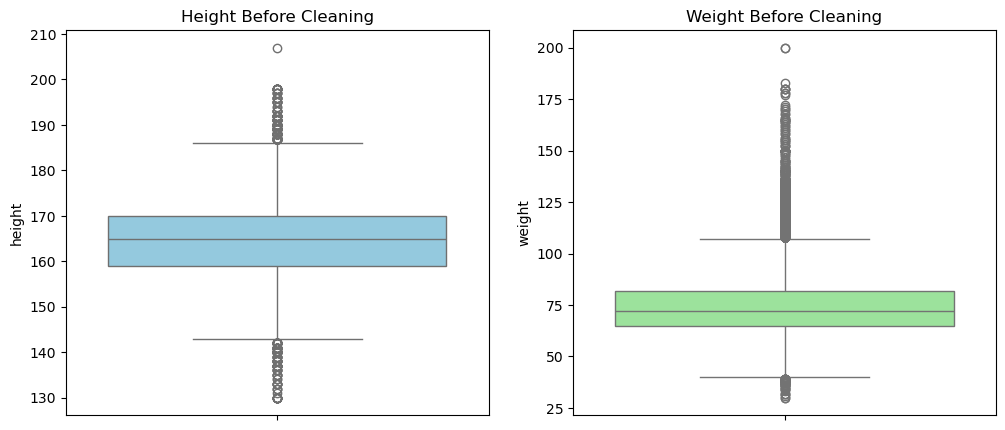

In [132]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(y=df["height"], ax=axes[0], color="skyblue")
axes[0].set_title("Height Before Cleaning")

sns.boxplot(y=df["weight"], ax=axes[1], color="lightgreen")
axes[1].set_title("Weight Before Cleaning")

plt.show()

In [133]:
rows_before = df.shape[0]

df = df[(df["height"] >= 130) & (df["height"] <= 210)]
df = df[(df["weight"] >= 30) & (df["weight"] <= 200)]

rows_after = df.shape[0]

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 68573
Rows after : 68573
Rows removed: 0


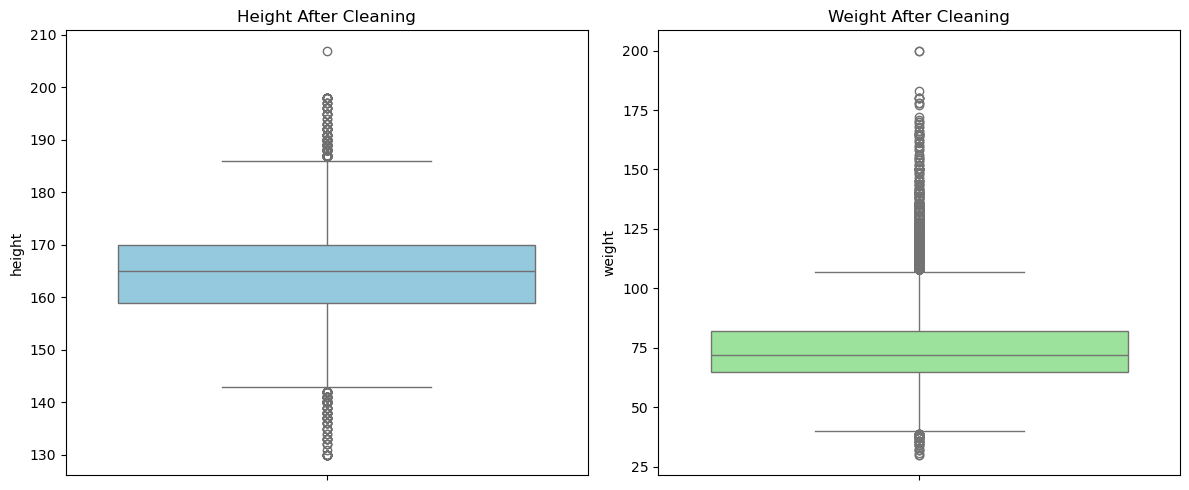

In [134]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(y=df["height"], ax=axes[0], color="skyblue")
axes[0].set_title("Height After Cleaning")

sns.boxplot(y=df["weight"], ax=axes[1], color="lightgreen")
axes[1].set_title("Weight After Cleaning")

plt.tight_layout()
plt.show()

### Blood Pressure 



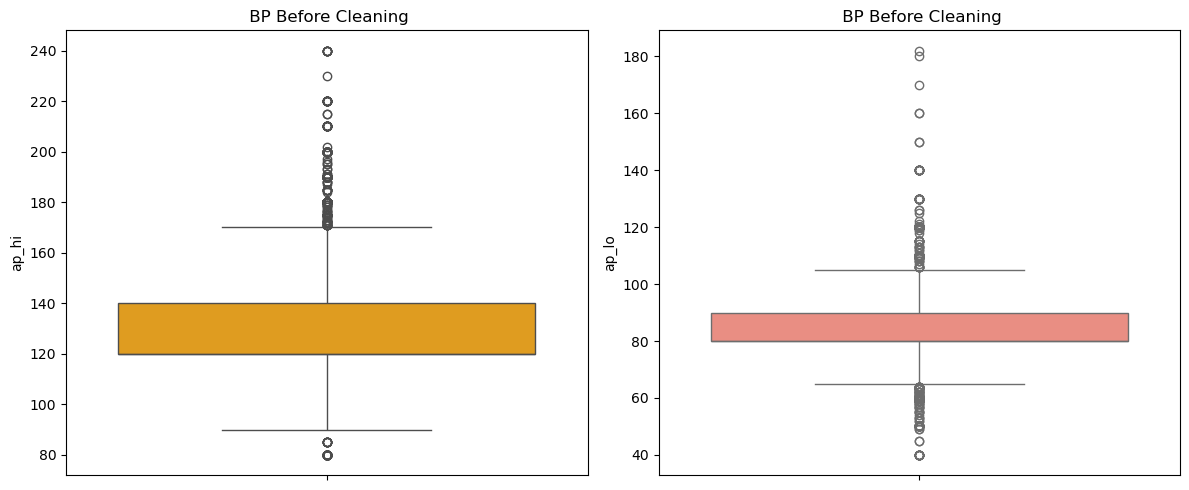

In [136]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(y=df["ap_hi"], ax=axes[0], color="orange")
axes[0].set_title(" BP Before Cleaning")

sns.boxplot(y=df["ap_lo"], ax=axes[1], color="salmon")
axes[1].set_title(" BP Before Cleaning")

plt.tight_layout()
plt.show()

In [137]:
rows_before = df.shape[0]

df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] > df["ap_lo"]]

rows_after = df.shape[0]

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 68573
Rows after : 68573
Rows removed: 0


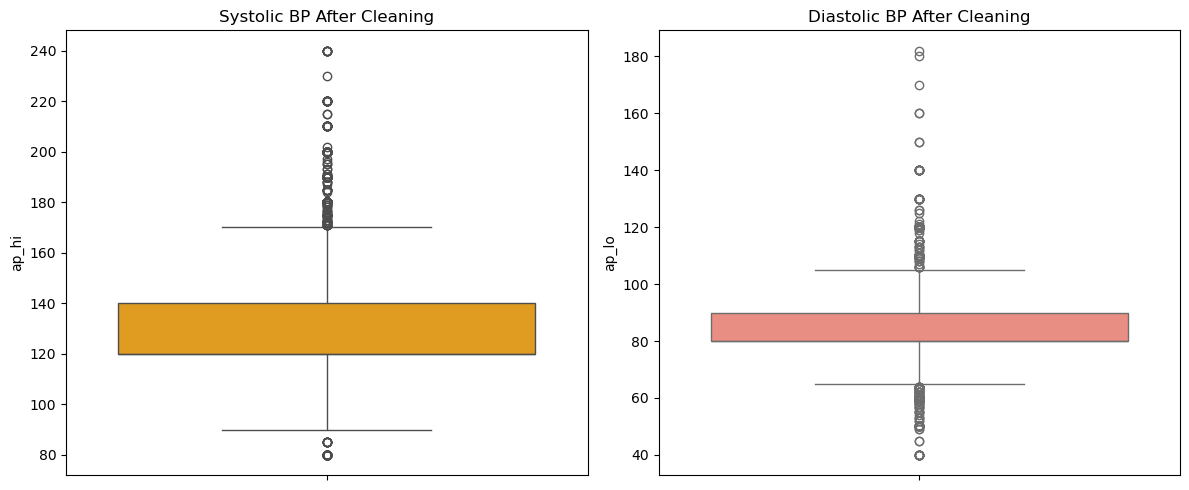

In [139]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.boxplot(y=df["ap_hi"], ax=axes[0], color="orange")
axes[0].set_title("Systolic BP After Cleaning")

sns.boxplot(y=df["ap_lo"], ax=axes[1], color="salmon")
axes[1].set_title("Diastolic BP After Cleaning")

plt.tight_layout()
plt.show()

In [141]:
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

df = df.drop(columns=['id', 'age'])

df[['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']].head()

KeyError: "['id', 'age'] not found in axis"

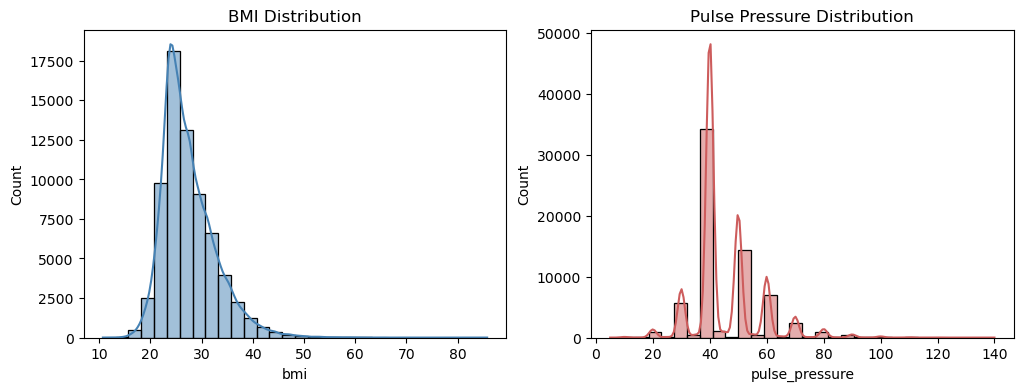

In [131]:

df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)


df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BMI Distribution')

sns.histplot(df['pulse_pressure'], bins=30, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Pulse Pressure Distribution')

plt.show()

In [115]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[continuous_cols] = scaler.fit_transform(df[continuous_cols])

df_scaled.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure
0,2,0.453931,-0.847695,-0.999673,-0.138827,1,1,0,0,1,0,-0.434502,-1.051783,-1.317580
1,1,-1.075277,0.761966,0.798090,0.919478,3,1,0,0,1,1,0.309052,1.437914,0.396885
2,1,0.071629,-0.707724,0.198836,-1.197131,3,1,0,0,0,1,-0.246486,-0.755820,1.254117
3,2,0.581365,0.552010,1.397344,1.977782,1,1,0,0,1,1,-0.746511,0.243603,0.396885
4,1,-1.075277,-1.267607,-1.598927,-2.255436,1,1,0,0,0,0,-0.806887,-0.851221,-0.460348


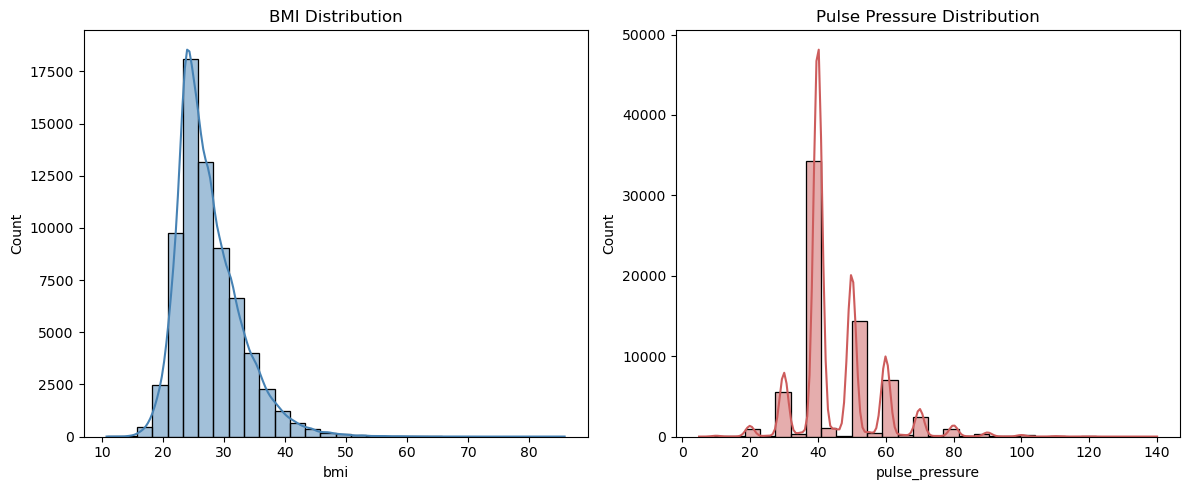

In [142]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df["bmi"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("BMI Distribution")

sns.histplot(df["pulse_pressure"], bins=30, kde=True, ax=axes[1], color="indianred")
axes[1].set_title("Pulse Pressure Distribution")

plt.tight_layout()
plt.show()

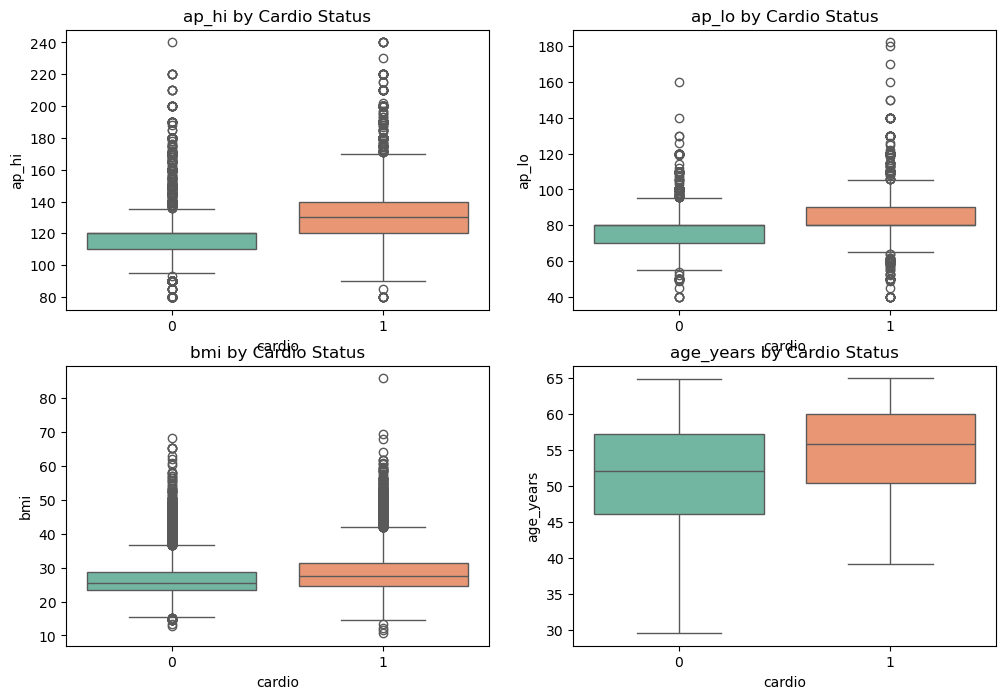

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), ['ap_hi', 'ap_lo', 'bmi', 'age_years']):
    sns.boxplot(
        data=df,
        x='cardio',
        y=col,
        hue='cardio',
        palette='Set2',
        legend=False,
        ax=ax
    )
    ax.set_title(f'{col} by Cardio Status')

plt.show()

cardio
0    34645
1    33928
Name: count, dtype: int64

cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


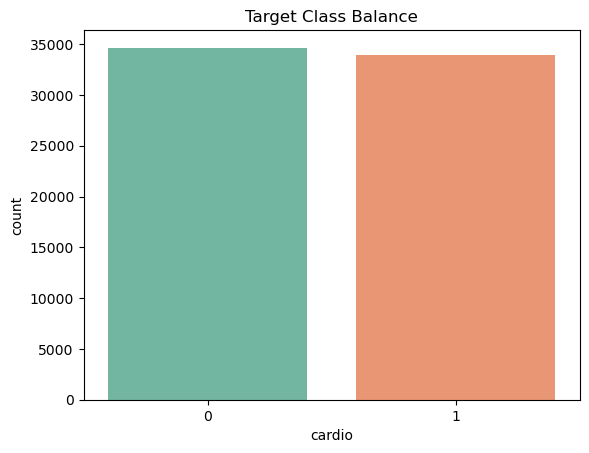

In [143]:
print(df["cardio"].value_counts())

print()

print(df["cardio"].value_counts(normalize=True).round(3))

sns.countplot(
    x="cardio",
    hue="cardio",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Target Class Balance")

plt.show()

In [118]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df.to_csv("cardio_cleaned.csv", index=False)
df_scaled.to_csv("cardio_cleaned_scaled.csv", index=False)

print("Saved cardio_cleaned.csv shape:", df.shape)
print("Saved cardio_cleaned_scaled.csv shape:", df_scaled.shape)

Saved cardio_cleaned.csv shape: (68573, 14)
Saved cardio_cleaned_scaled.csv shape: (68573, 14)


In [121]:
from sklearn.model_selection import train_test_split

In [122]:

X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Summary of Week 2 Data Preprocessing
- **Initial Dataset:** 70,000 patient records from `cardio_train.csv`.
- **Missing Values:** 0 missing entries detected.
- **Outlier Removal:** Filtered physiological anomalies in height (130-210 cm), weight (30-200 kg), and blood pressure (`ap_hi` 80-250 mmHg, `ap_lo` 40-180 mmHg, and `ap_hi > ap_lo`).
- **Feature Engineering:** Calculated `age_years` (age in years), `bmi` (Body Mass Index), and `pulse_pressure` (`ap_hi - ap_lo`).
- **Data Export:** Cleaned dataset saved as `cardio_cleaned.csv` (68,573 rows) and scaled dataset as `cardio_cleaned_scaled.csv` for downstream model training.
